**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df
from darksun.utils import savefig_to

**Analysis Methods**

In [2]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    angles_x, angles_y = [], []
    for sourceID in log.log['ID']:
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'angle_x': angles_x, 'angle_y': angles_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    angles_x, angles_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - angles_x),
        60 * np.abs(np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    fluences = []
    for sourceID in log.log['ID']:
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> NDArray:
    """
    Computes the percentage fluence residues between the IROS
    and the catalogue sources.
    """
    df = extract_catalogue_fluences(log, catalogue, sdl, camera, verbose)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences
    return res * 100 / fluences


def reconstruction_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, verbose,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'Brightest': log.log['id_brightest'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    return dict2df(dmap)

In [3]:
def are_same_sources(first: Log, second: Log) -> bool:
    """
    Checks if the sources in the two logs are the same
    and equally sorted.
    """
    arr_first, arr_sec = map(np.array, (first.log['ID'], second.log['ID']))
    return bool(np.all(np.array(arr_first) == np.array(arr_sec)))

**General Variables**

In [4]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/detector_smoothing/smoothing'
SAVE_THINGS: bool = False

**Mask and Data Specifics**

In [5]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"

ANALYSIS_IDs: tuple[str, ...] = (
    #"singleCAM_iros_upx5upy1_newOptimiser",
    #"singleCAM_iros_upx5upy1_10um",
    "singleCAM_iros_upx5upy1_newOptimiser_smoothing",
    "singleCAM_iros_upx5upy1_10um_smoothing",
)

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

In [6]:
# load filepaths
mask_path, simul_data, _ = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

**Load Databases with IROS runs**

In [7]:
basepath: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

logs_camA, logs_camB = zip(
    *tuple(
        ds.load_database(f"{basepath}/{test}/IROS_sources_database_TEST_{test}.fits")
        for test in ANALYSIS_IDs
    )
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


**Load WISEMAN data**

In [8]:
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

**Residues benchmark plots - Camera A**

In [16]:
# camera A
logA, logA_10um = logs_camA

assert are_same_sources(logA, logA_10um), "Sources are NOT the same!!!"

angular_coords = extract_catalogue_angular_coords(logA, catalogueA, sdlA, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    logA, catalogueA, sdlA, wfm,
)
fluence_res = get_fluence_residues(
    logA, catalogueA, sdlA, wfm, False,
)

theta_res_x_10um, theta_res_y_10um = get_angularcoords_residues(
    logA_10um, catalogueA, sdlA, wfm,
)
fluence_res_10um = get_fluence_residues(
    logA_10um, catalogueA, sdlA, wfm, False,
)

/tmp/ipykernel_13319/3969725637.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


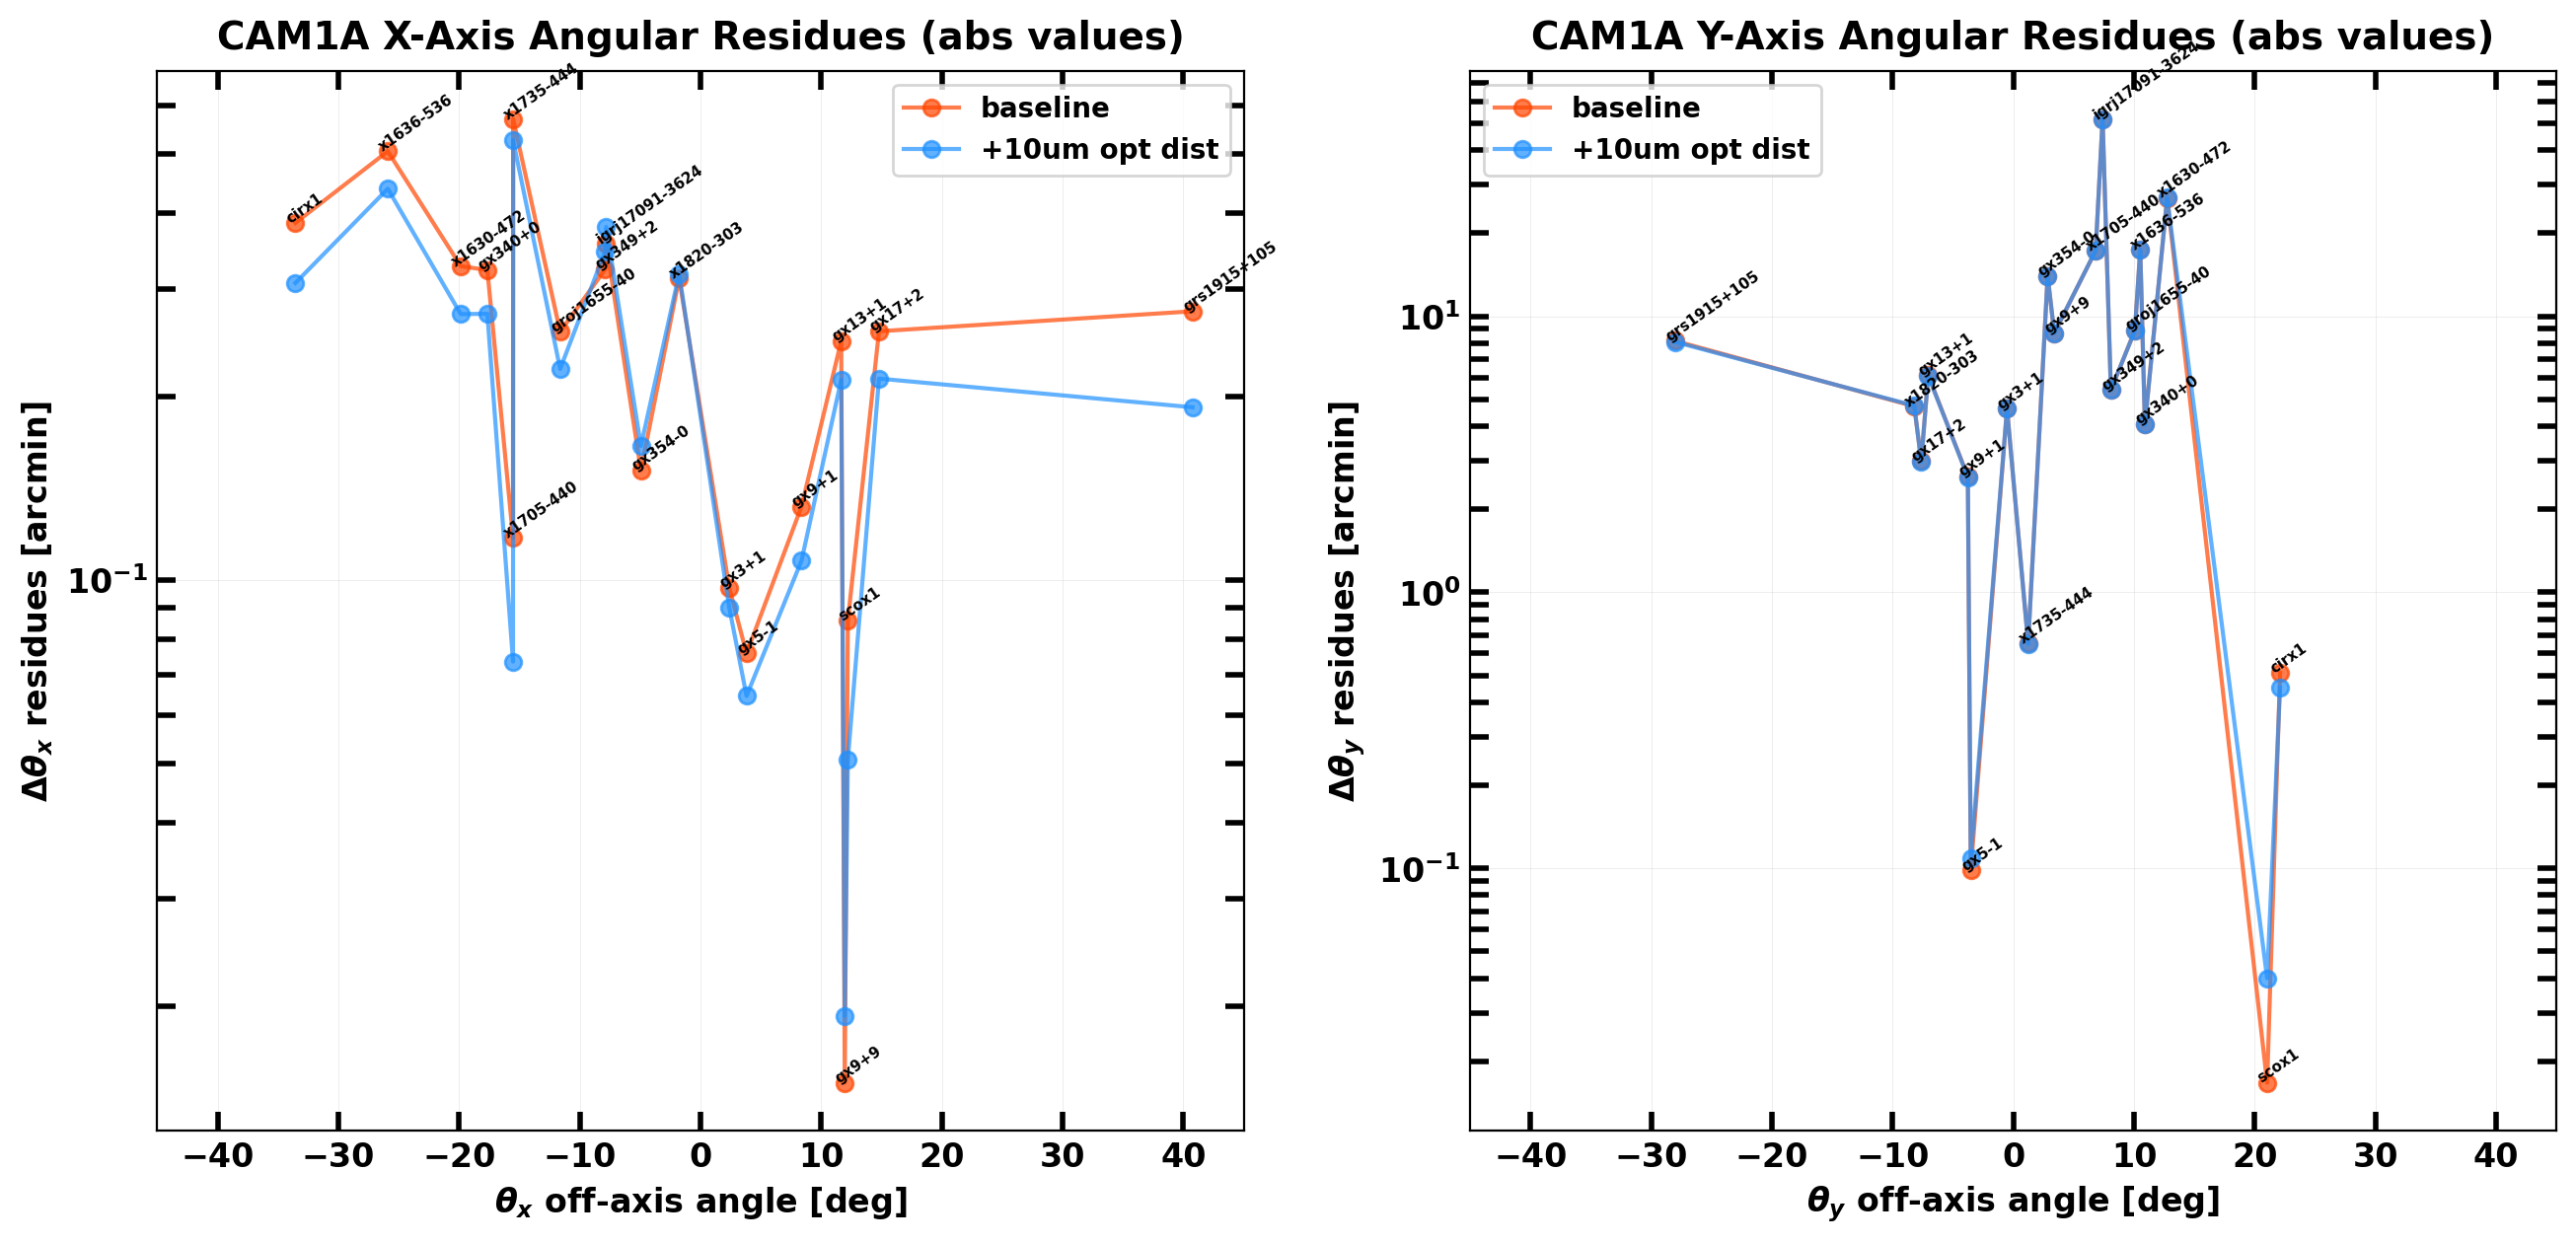

In [42]:
from darksun.show import DSPlot

dmap_res_x = {
    'ID': logA.log['ID'],
    'theta_res': theta_res_x,
    'theta_res_10um': theta_res_x_10um,
    'theta_true': cat_theta_x,
}
dmap_res_y = {
    'ID': logA.log['ID'],
    'theta_res': theta_res_y,
    'theta_res_10um': theta_res_y_10um,
    'theta_true': cat_theta_y,
}

df_x = pd.DataFrame(dmap_res_x).sort_values('theta_true')
df_y = pd.DataFrame(dmap_res_y).sort_values('theta_true')



dsp = DSPlot(2, 1)
alpha = 0.7

fig, axs = dsp.config_subplots()
for ax in axs:
    dsp.config_ticks(ax)
    dsp.config_axscale(ax, 'linear', 'log')

# add axis 0
dsp.config_labels(
    axs[0],
    'CAM1A X-Axis Angular Residues (abs values)',
    '$\\theta_{{x}}$ off-axis angle [deg]',
    '$\\Delta\\theta_{{x}}$ residues [arcmin]',
)
axs[0].plot(df_x['theta_true'], df_x['theta_res'], 'o-', c='OrangeRed', alpha=alpha, label='baseline')
axs[0].plot(df_x['theta_true'], df_x['theta_res_10um'], 'o-', c='DodgerBlue', alpha=alpha, label='+10um opt dist')
for (_name, _x, _y) in zip(df_x['ID'], df_x['theta_true'], df_x['theta_res']):
    axs[0].text(
        _x - 1, _y, _name, color='black',fontsize=0.9*6, fontweight='bold', rotation=35,
    )
dsp.config_axlim(axs[0], (-45, 45), (None, None))
axs[0].legend(loc='best')

# add axis 1
dsp.config_labels(
    axs[1],
    'CAM1A Y-Axis Angular Residues (abs values)',
    '$\\theta_{{y}}$ off-axis angle [deg]',
    '$\\Delta\\theta_{{y}}$ residues [arcmin]',
)
axs[1].plot(df_y['theta_true'], df_y['theta_res'], 'o-', c='OrangeRed', alpha=alpha, label='baseline')
axs[1].plot(df_y['theta_true'], df_y['theta_res_10um'], 'o-', c='DodgerBlue', alpha=alpha, label='+10um opt dist')
for (_name, _x, _y) in zip(df_y['ID'], df_y['theta_true'], df_y['theta_res']):
    axs[1].text(
        _x - 1, _y, _name, color='black',fontsize=0.9*6, fontweight='bold', rotation=35,
    )
dsp.config_axlim(axs[1], (-45, 45), (None, None))
axs[1].legend(loc='best')

fig.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


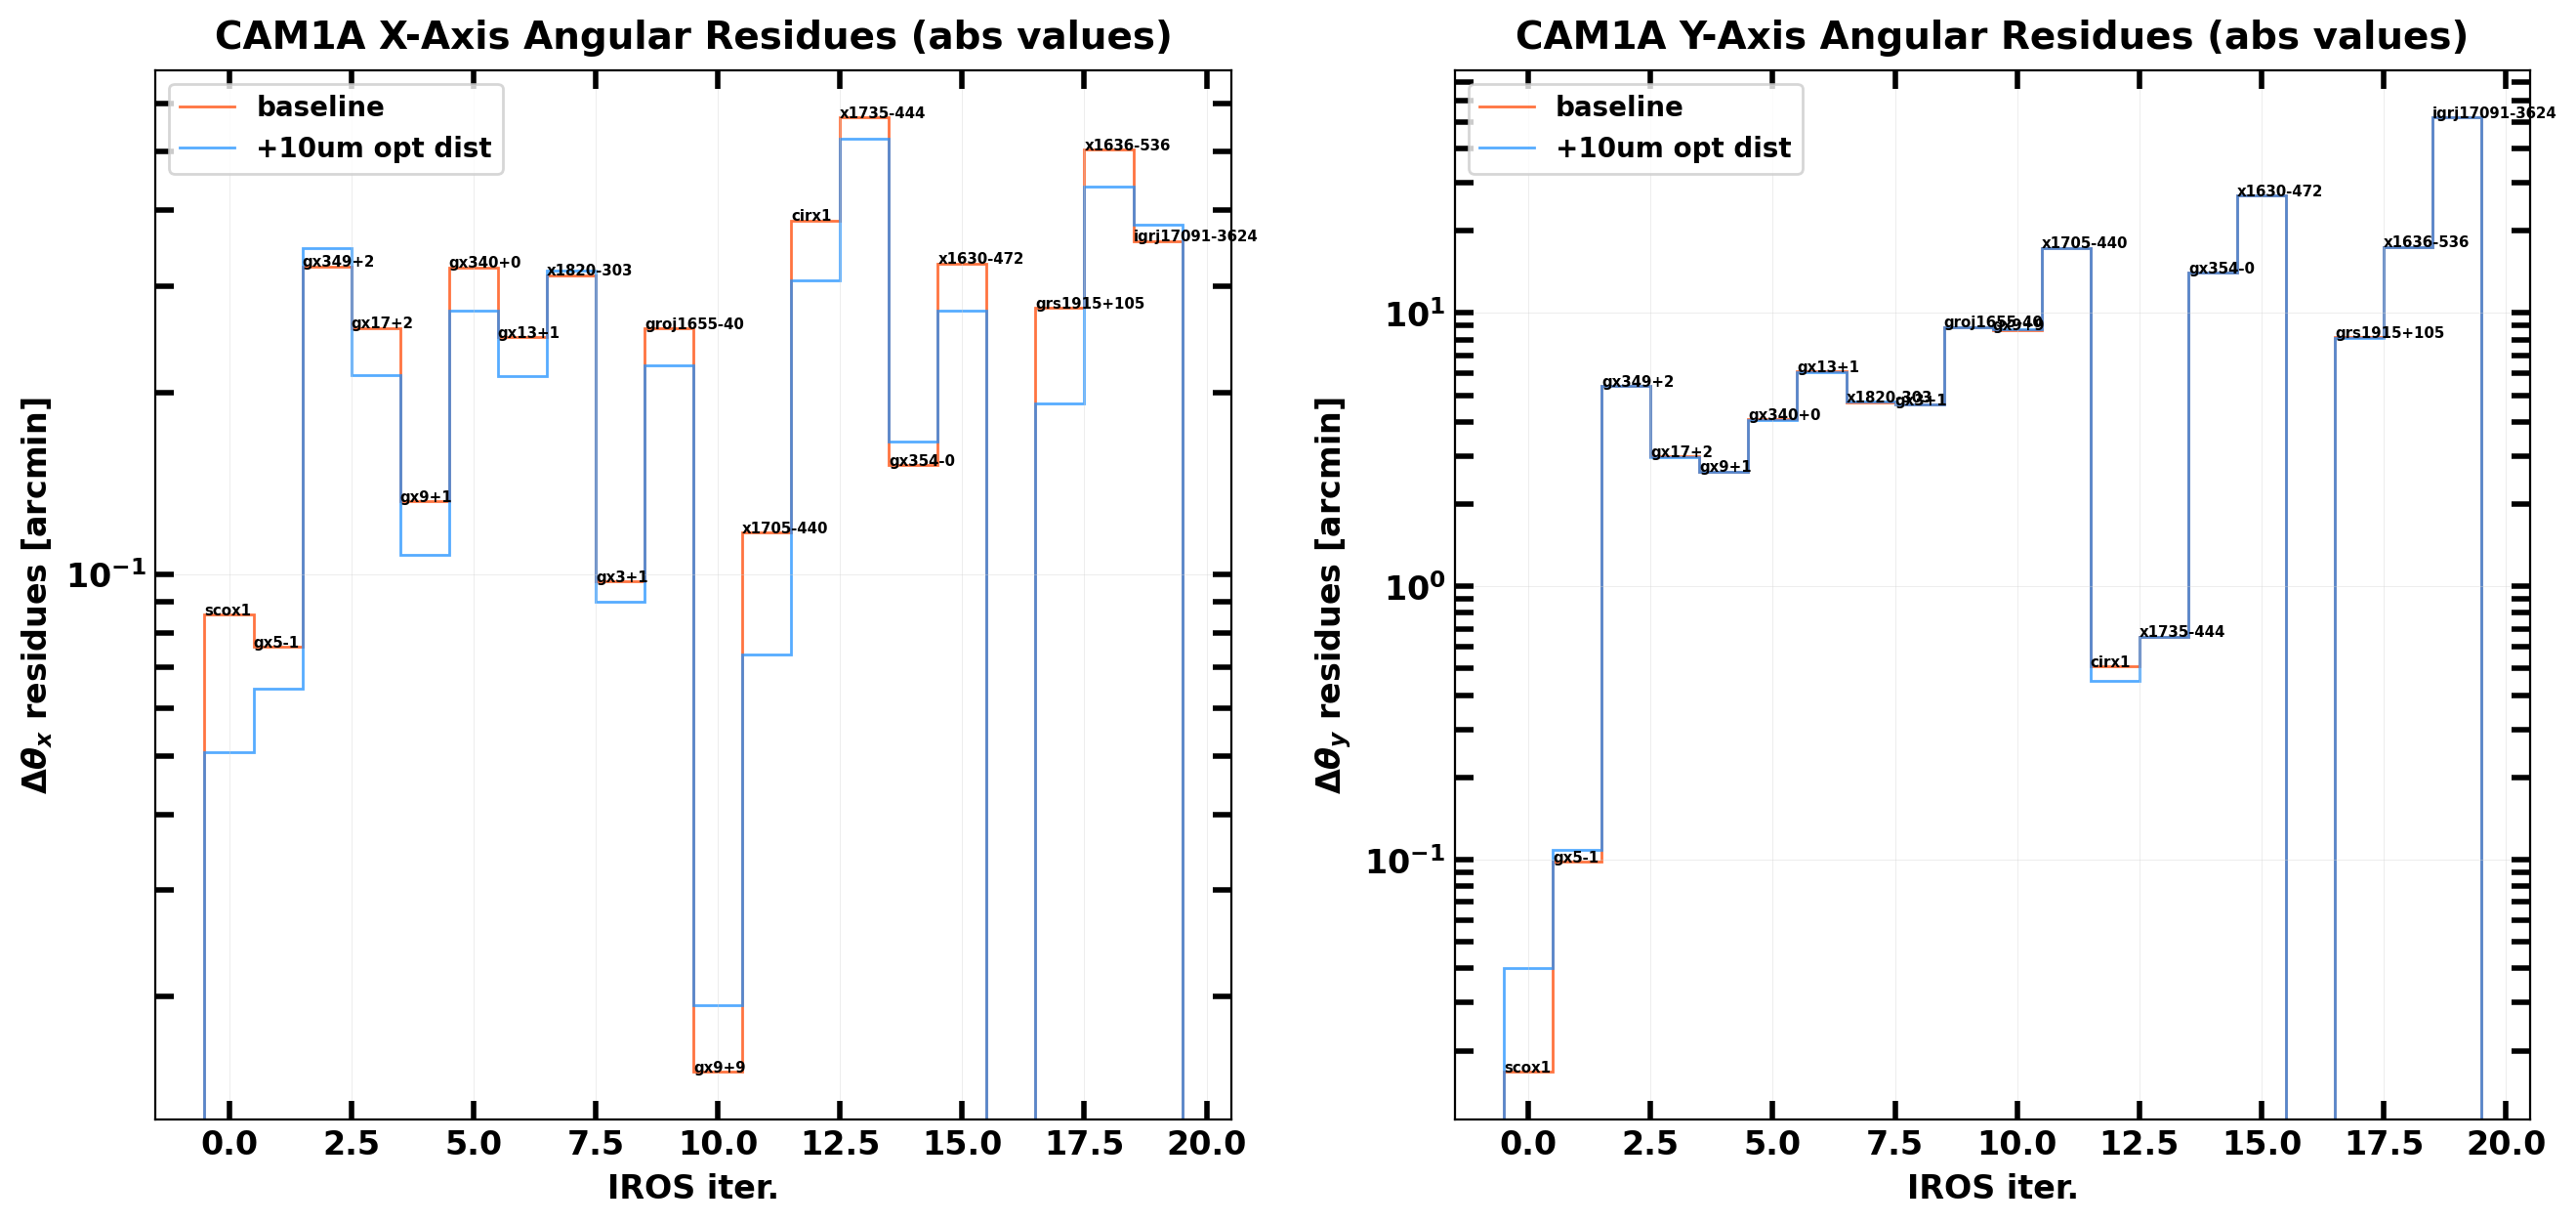

In [43]:
x = np.arange(len(logA.log['ID']) + 1) - 0.5

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logA.log['ID'], theta_res_x, x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logA.log['ID'], theta_res_y, x,
    )
)
dmapx = ds.map4plot(
    arrs=(theta_res_x, theta_res_x_10um),
    title='CAM1A X-Axis Angular Residues (abs values)',
    xlabel='IROS iter.',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    labels=('baseline', '+10um opt dist'),    
    x=x,
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
    #xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=(theta_res_y, theta_res_y_10um),
    title='CAM1A Y-Axis Angular Residues (abs values)',
    xlabel='IROS iter.',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    labels=('baseline', '+10um opt dist'),
    x=x,
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
    #xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


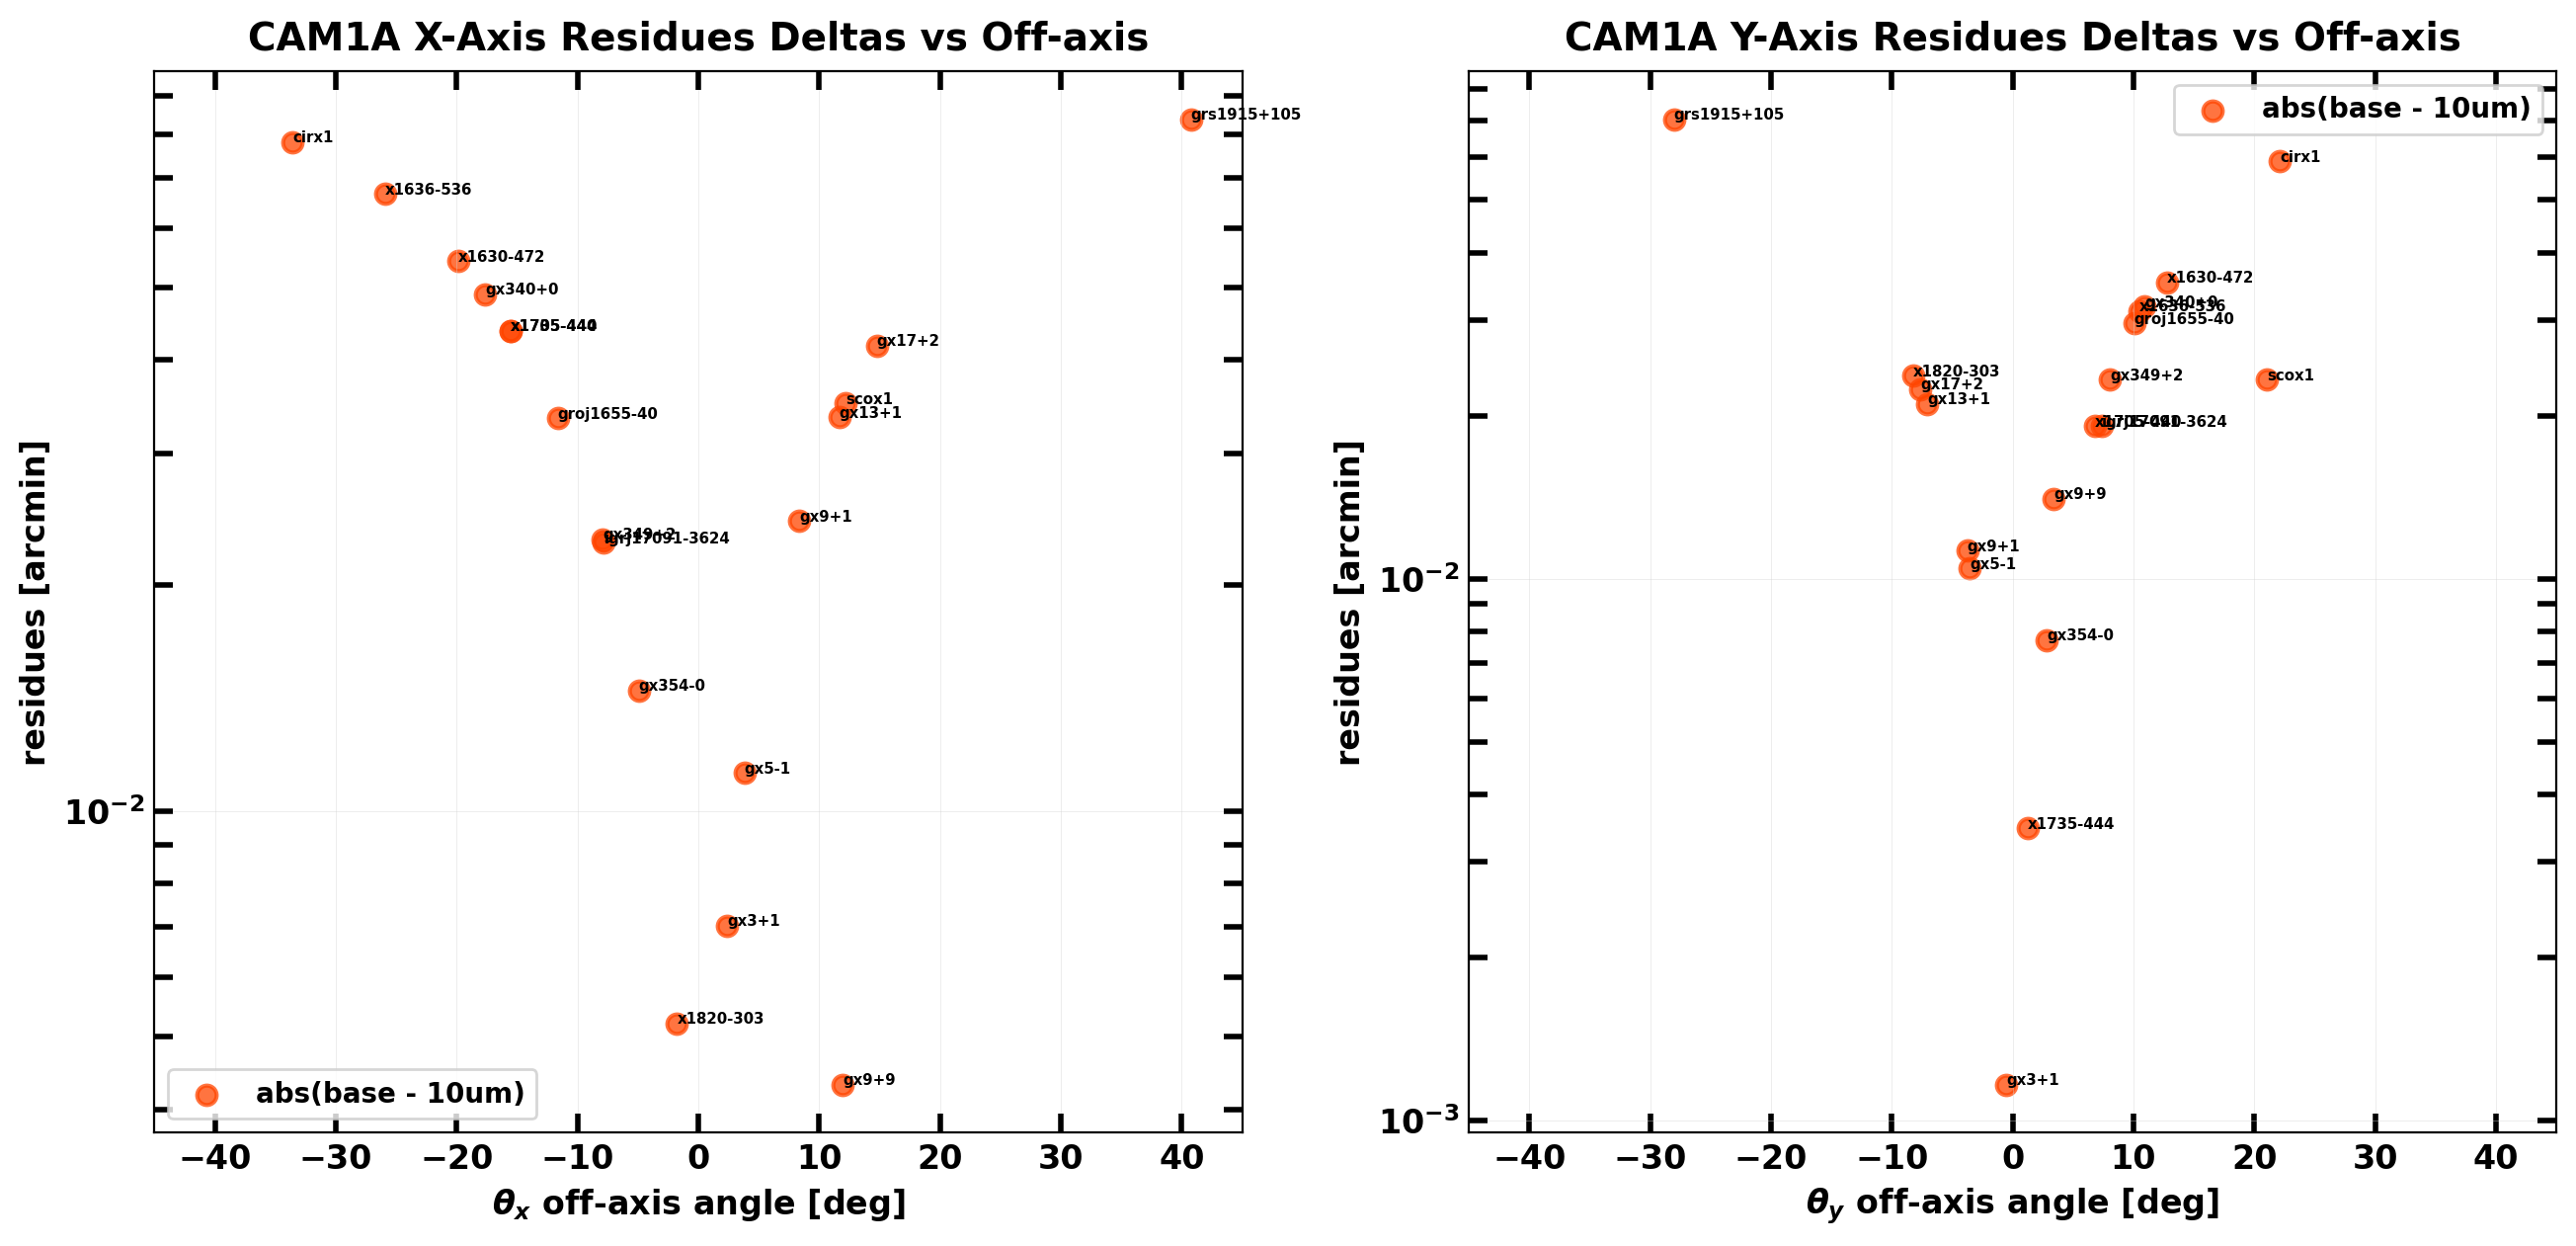

In [12]:
ddelta_x = np.abs(theta_res_x - theta_res_x_10um)
ddelta_y = np.abs(theta_res_y - theta_res_y_10um)

tags_x_deltas = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logA.log['ID'], ddelta_x, cat_theta_x,
    )
)
tags_y_deltas = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logA.log['ID'], ddelta_y, cat_theta_y,
    )
)
dmapx_deltas = ds.map4plot(
    arrs=ddelta_x,
    title='CAM1A X-Axis Residues Deltas vs Off-axis',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='residues [arcmin]',
    labels='abs(base - 10um)',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x_deltas,
)
dmapy_deltas = ds.map4plot(
    arrs=ddelta_y,
    title='CAM1A Y-Axis Residues Deltas vs Off-axis',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='residues [arcmin]',
    labels='abs(base - 10um)',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y_deltas,
)

ds.plot(
    (dmapx_deltas, dmapy_deltas),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

<br>

<br>

**Residues benchmark plots - Camera B**

In [13]:
# camera B
logB, logB_10um = logs_camB

assert are_same_sources(logB, logB_10um), "Sources are NOT the same!!!"

angular_coords = extract_catalogue_angular_coords(logB, catalogueB, sdlB, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    logB, catalogueB, sdlB, wfm,
)
fluence_res = get_fluence_residues(
    logB, catalogueB, sdlB, wfm, False,
)

theta_res_x_10um, theta_res_y_10um = get_angularcoords_residues(
    logB_10um, catalogueB, sdlB, wfm,
)
fluence_res_10um = get_fluence_residues(
    logB_10um, catalogueB, sdlB, wfm, False,
)

In [ ]:
from darksun.show import DSPlot

dmap_res_x = {
    'ID': logB.log['ID'],
    'theta_res': theta_res_x,
    'theta_res_10um': theta_res_x_10um,
    'theta_true': cat_theta_x,
}
dmap_res_y = {
    'ID': logB.log['ID'],
    'theta_res': theta_res_y,
    'theta_res_10um': theta_res_y_10um,
    'theta_true': cat_theta_y,
}

df_x = pd.DataFrame(dmap_res_x).sort_values('theta_true')
df_y = pd.DataFrame(dmap_res_y).sort_values('theta_true')



dsp = DSPlot(2, 1)
alpha = 0.7

fig, axs = dsp.config_subplots()
for ax in axs:
    dsp.config_ticks(ax)
    dsp.config_axscale(ax, 'linear', 'log')

# add axis 0
dsp.config_labels(
    axs[0],
    'CAM1B X-Axis Angular Residues (abs values)',
    '$\\theta_{{x}}$ off-axis angle [deg]',
    '$\\Delta\\theta_{{x}}$ residues [arcmin]',
)
axs[0].plot(df_x['theta_true'], df_x['theta_res'], 'o-', c='OrangeRed', alpha=alpha, label='baseline')
axs[0].plot(df_x['theta_true'], df_x['theta_res_10um'], 'o-', c='DodgerBlue', alpha=alpha, label='+10um opt dist')
for (_name, _x, _y) in zip(df_x['ID'], df_x['theta_true'], df_x['theta_res']):
    axs[0].text(
        _x - 1, _y, _name, color='black',fontsize=0.9*6, fontweight='bold', rotation=35,
    )
dsp.config_axlim(axs[0], (-45, 45), (None, None))
axs[0].legend(loc='best')

# add axis 1
dsp.config_labels(
    axs[1],
    'CAM1B Y-Axis Angular Residues (abs values)',
    '$\\theta_{{y}}$ off-axis angle [deg]',
    '$\\Delta\\theta_{{y}}$ residues [arcmin]',
)
axs[1].plot(df_y['theta_true'], df_y['theta_res'], 'o-', c='OrangeRed', alpha=alpha, label='baseline')
axs[1].plot(df_y['theta_true'], df_y['theta_res_10um'], 'o-', c='DodgerBlue', alpha=alpha, label='+10um opt dist')
for (_name, _x, _y) in zip(df_y['ID'], df_y['theta_true'], df_y['theta_res']):
    axs[1].text(
        _x - 1, _y, _name, color='black',fontsize=0.9*6, fontweight='bold', rotation=35,
    )
dsp.config_axlim(axs[1], (-45, 45), (None, None))
axs[1].legend(loc='best')

fig.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


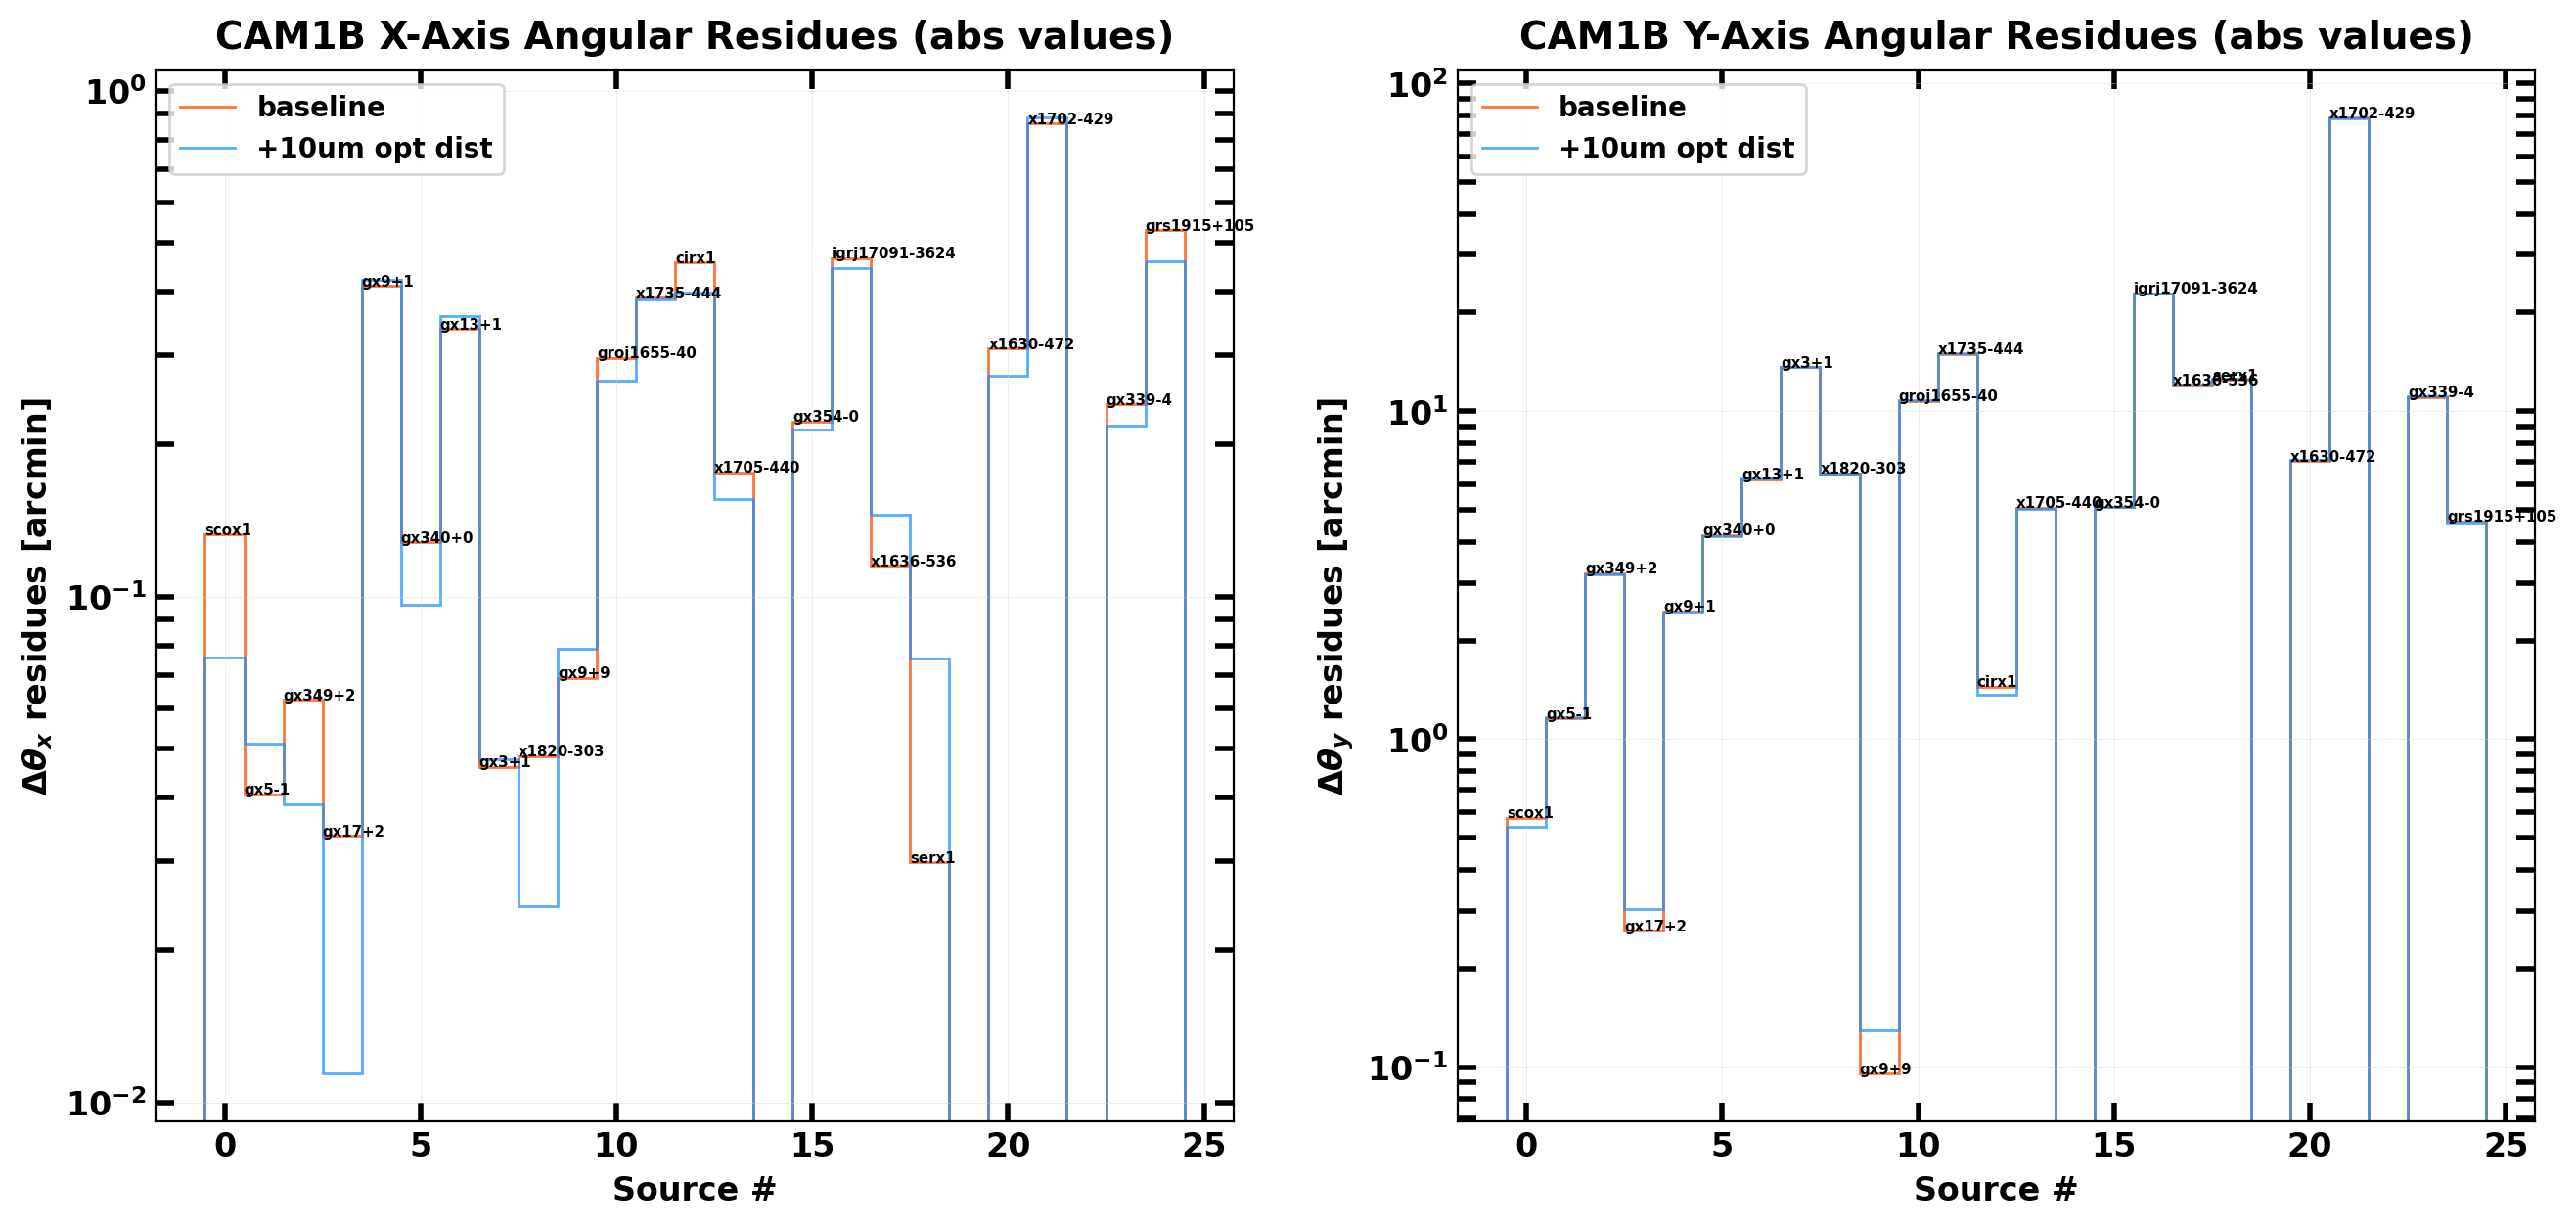

In [ ]:
x = np.arange(len(logB.log['ID']) + 1) - 0.5

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logB.log['ID'], theta_res_x, x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logB.log['ID'], theta_res_y, x,
    )
)
dmapx = ds.map4plot(
    arrs=(theta_res_x, theta_res_x_10um),
    title='CAM1B X-Axis Angular Residues (abs values)',
    xlabel='IROS iter.',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    labels=('baseline', '+10um opt dist'),    
    x=x,
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
    #xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=(theta_res_y, theta_res_y_10um),
    title='CAM1B Y-Axis Angular Residues (abs values)',
    xlabel='IROS iter.',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    labels=('baseline', '+10um opt dist'),
    x=x,
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
    #xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


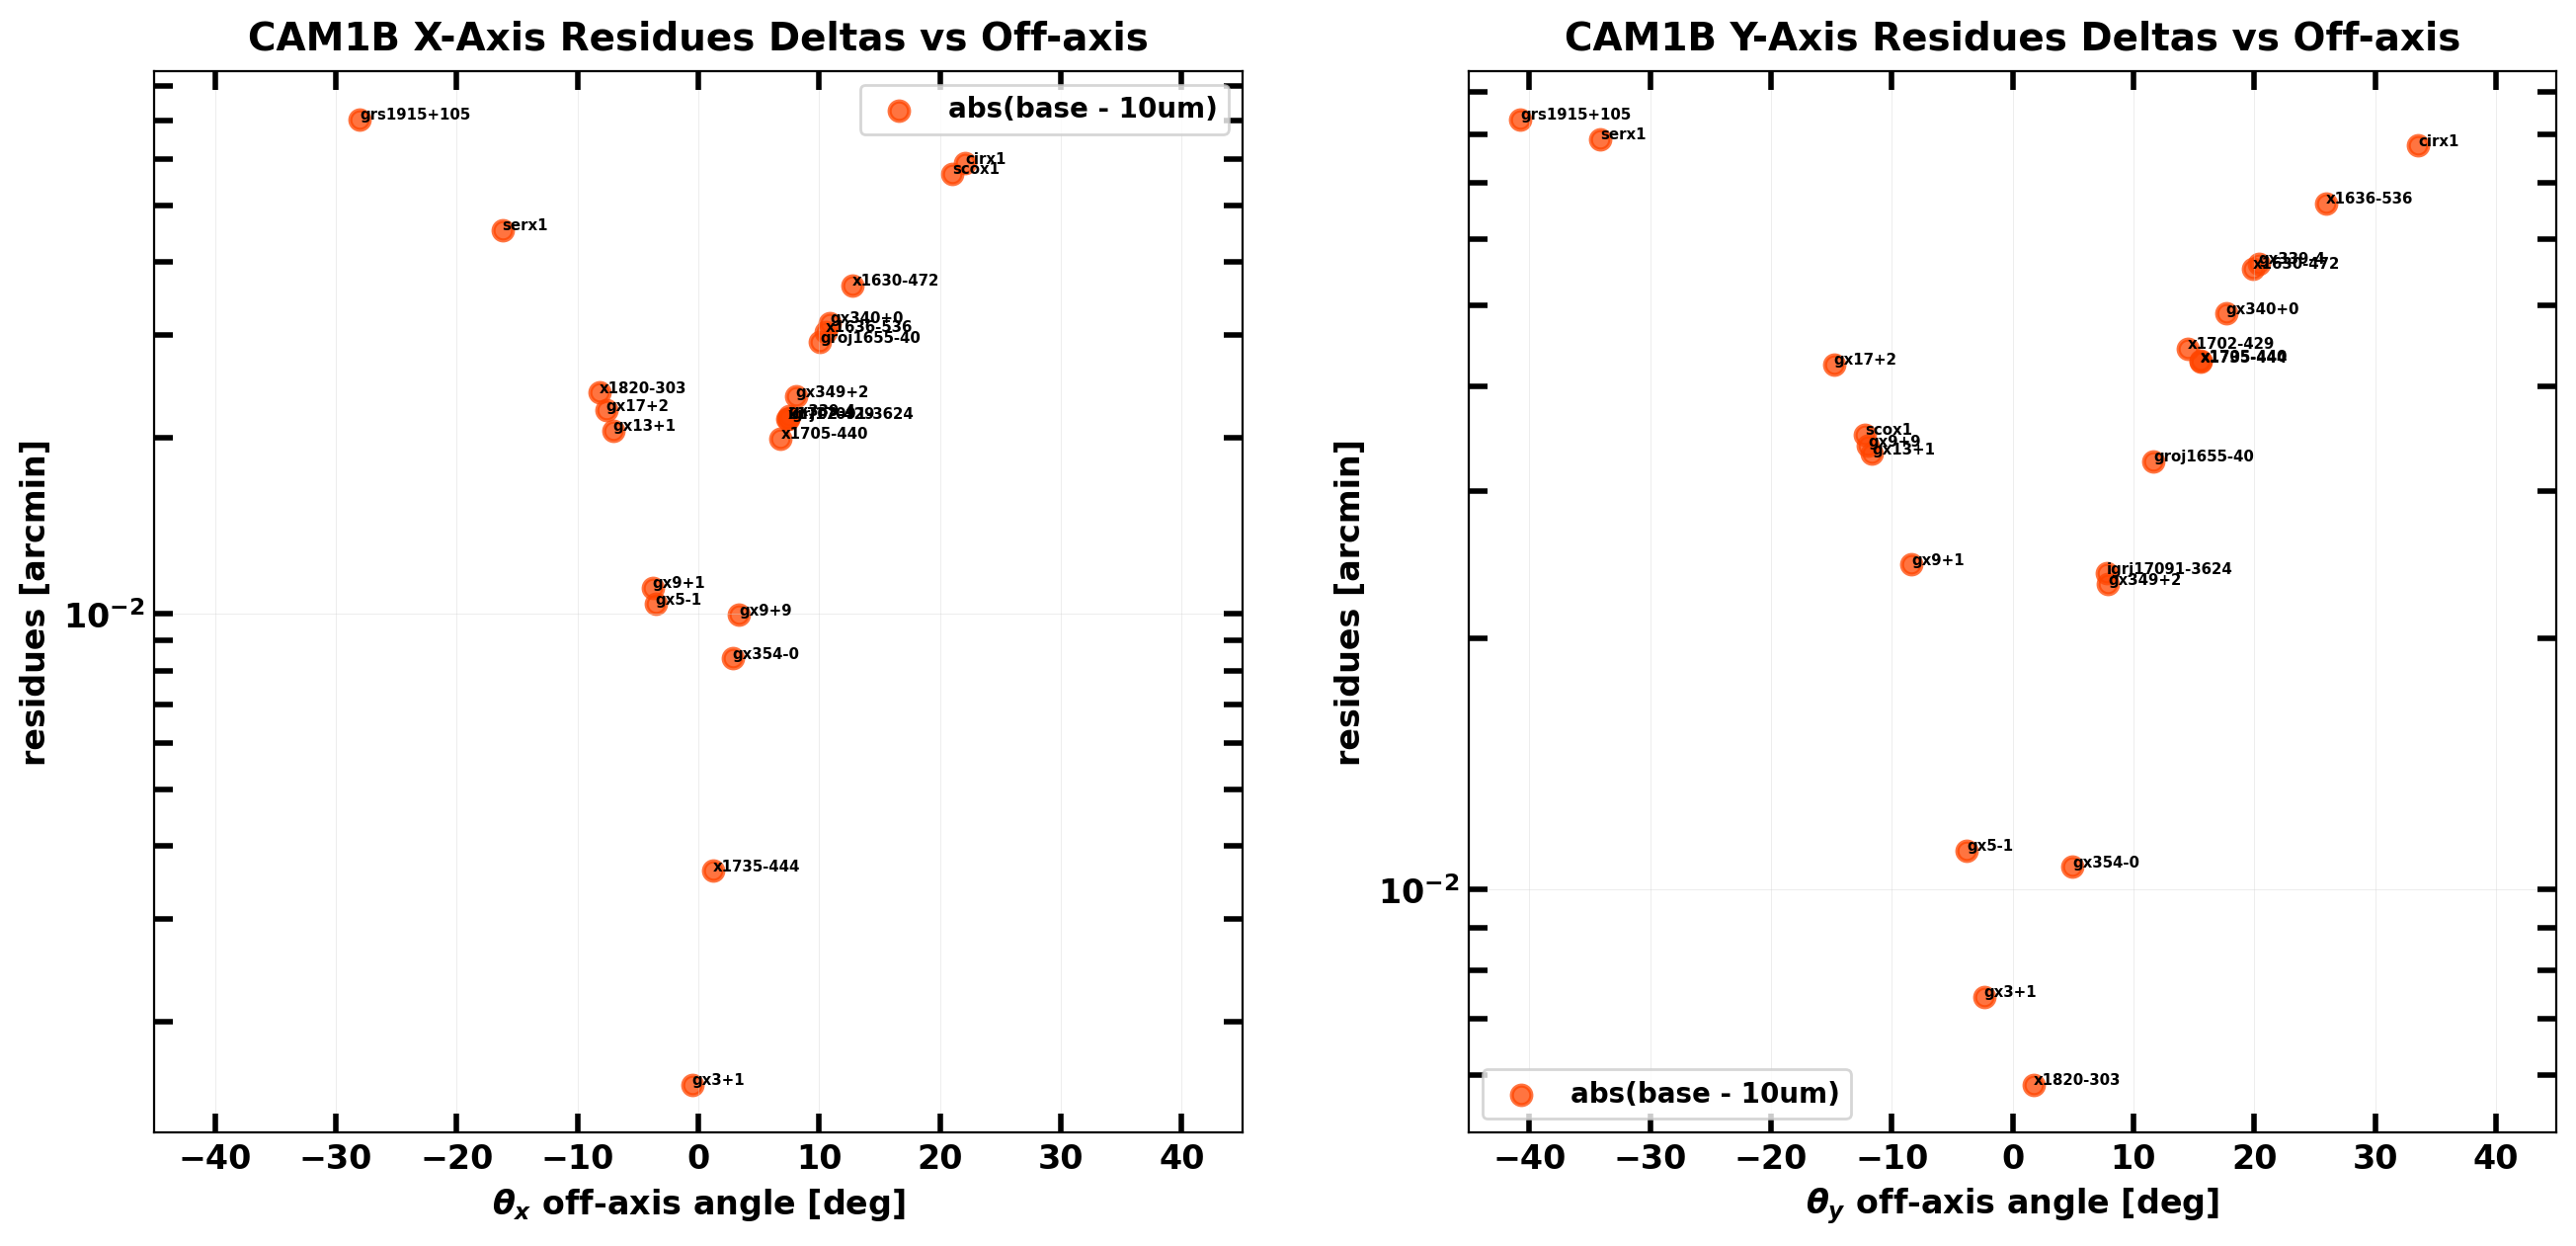

In [15]:
ddelta_x = np.abs(theta_res_x - theta_res_x_10um)
ddelta_y = np.abs(theta_res_y - theta_res_y_10um)

tags_x_deltas = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logB.log['ID'], ddelta_x, cat_theta_x,
    )
)
tags_y_deltas = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        logB.log['ID'], ddelta_y, cat_theta_y,
    )
)
dmapx_deltas = ds.map4plot(
    arrs=ddelta_x,
    title='CAM1B X-Axis Residues Deltas vs Off-axis',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='residues [arcmin]',
    labels='abs(base - 10um)',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x_deltas,
)
dmapy_deltas = ds.map4plot(
    arrs=ddelta_y,
    title='CAM1B Y-Axis Residues Deltas vs Off-axis',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='residues [arcmin]',
    labels='abs(base - 10um)',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y_deltas,
)

ds.plot(
    (dmapx_deltas, dmapy_deltas),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)